In [8]:
!pip install -q PyPortfolioOpt
!pip install -q yfinance

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt import objective_functions

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

In [2]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270309,170.404495,41.931019,54.393024,76.912781,63.700039,540.298584,101.482430,341.154053,75.843292,...,154.084091,147.359741,392.184082,29.220690,453.210358,399.926666,230.069717,45.828430,45.858700,55.125244
2022-01-04,176.007782,167.522003,43.574482,54.815407,77.167389,66.463226,537.934082,103.328964,343.197235,79.329277,...,154.306793,147.875397,387.097229,30.639351,453.058594,383.196655,229.634140,47.653255,45.018566,57.198727
2022-01-05,171.326019,164.356995,42.839012,54.177521,77.485611,65.323402,524.291016,104.001205,339.670776,77.873314,...,154.832367,148.544815,375.205261,30.639351,444.358887,362.706665,224.653412,47.237705,45.627270,57.910130
2022-01-06,168.465973,163.253998,43.701599,55.953266,76.976425,67.775742,524.176636,104.886169,338.084778,79.470695,...,154.867981,147.296478,374.941620,31.367107,443.941498,354.899994,224.596603,48.448235,45.500454,59.272202
2022-01-07,168.632477,162.554001,44.654991,56.703209,76.776398,69.632233,511.191437,106.392319,338.010162,81.667130,...,155.063950,147.215073,370.879944,32.269882,442.186371,342.320007,223.573959,49.478085,45.934795,59.758030


# Setting Up Markowitz Portfolio Theory

First, let us set up Markowitz Portfolio Theory. Let $r$ be a matrix of T historical daily log returns of n stocks:

$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$

where:  
- $T$ is the number of days, so $T=752$  
- $n$ is number of stocks, so $n=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$

For our case, $r$ is 
Then $\hat{\mu}$ is a vector of means of annualized expected log return:

$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$

and $\hat{\Sigma}$ is the variance-covariance matrix of nnualized expected log return:

$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$

where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock.  

    Stock   Weight
0    AAPL  0.00000
1    AMZN  0.00000
2     BAC  0.00000
3       C  0.00000
4      CL  0.00000
5     COP  0.00000
6    COST  0.00000
7     CVX  0.00000
8     DIA  0.00000
9     EOG  0.00000
10  GOOGL  0.00000
11     GS  0.00000
12    IWM  0.00000
13    JPM  0.00000
14     KO  0.00000
15   META  0.00000
16    MPC  0.14690
17     MS  0.00000
18   MSFT  0.00000
19   NVDA  0.14750
20    PEP  0.00000
21     PG  0.00000
22    QQQ  0.00000
23    SLB  0.00000
24    SPY  0.00000
25   TSLA  0.00000
26    VTI  0.00000
27    WFC  0.00000
28    WMT  0.56538
29    XOM  0.14021

Expected annual return: 25.3%
Annual volatility: 18.2%
Sharpe Ratio: 1.28


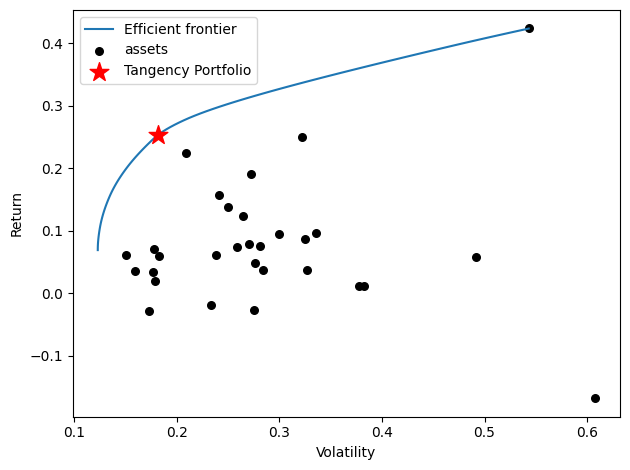

In [3]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items()],
    columns=['Stock', 'Weight']
)
print(weights_df)
print()
exp_return, vol, sharpe = ef_tan.portfolio_performance(verbose=True, risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)
plt.legend()
plt.show()

In [4]:
# Define date range
start = "2025-01-01"
end = "2025-03-01"

# Download historical data
close_test_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  30 of 30 completed


In [5]:
markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator(allocation=markowitz_allocator)

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
MPC      Markowitz Model      6.63%      0.08     -7.55%   100.00%      inf
NVDA     Markowitz Model     -9.74%     -0.04    -21.86%     0.00%     0.00
WMT      Markowitz Model      9.39%      0.14    -10.76%   100.00%      inf
XOM      Markowitz Model      4.55%      0.09     -4.86%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,537.70
Total Profit:          $537.70
Total Return:          5.38%
Sharpe Ratio:          0.12
Maximum Drawdown:      -6.93%
Volatility:            1.20%


In [6]:
markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator()

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
MPC      Markowitz Model      6.63%      0.08     -7.55%   100.00%      inf
NVDA     Markowitz Model     -9.74%     -0.04    -21.86%     0.00%     0.00
WMT      Markowitz Model      9.39%      0.14    -10.76%   100.00%      inf
XOM      Markowitz Model      4.55%      0.09     -4.86%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,260.37
Total Profit:          $260.37
Total Return:          2.60%
Sharpe Ratio:          0.05
Maximum Drawdown:      -6.66%
Volatility:            1.37%


In [7]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator(allocation='equal')

# 6. Run backtests and add each stock to portfolio
for stock in stocks:

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Equal Model")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     Equal Model         -0.81%     -0.01     -9.09%     0.00%     0.00
MSFT     Equal Model         -5.05%     -0.08    -12.03%     0.00%     0.00
NVDA     Equal Model         -9.74%     -0.04    -21.86%     0.00%     0.00
AMZN     Equal Model         -3.67%     -0.06    -13.66%     0.00%     0.00
GOOGL    Equal Model        -10.02%     -0.13    -18.06%     0.00%     0.00
META     Equal Model         10.91%      0.17    -10.37%   100.00%      inf
TSLA     Equal Model        -22.54%     -0.18    -33.77%     0.00%     0.00
JPM      Equal Model         10.60%      0.21     -7.97%   100.00%      inf
BAC      Equal Model          3.97%      0.08     -7.94%   100.00%      inf
WFC      Equa

In [8]:
markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator

new_markowitz_allocator = {'WMT': 0.30966, 'NVDA': 0.05203, 'MPC': 0.31915, 'XOM': 0.31915}
portfolio = PortfolioEvaluator()

portfolio = PortfolioEvaluator(allocation=new_markowitz_allocator)

# 6. Run backtests and add each stock to portfolio
for stock in new_markowitz_allocator.keys():
    alloc = new_markowitz_allocator[stock]

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
WMT      Markowitz Model      9.39%      0.14    -10.76%   100.00%      inf
NVDA     Markowitz Model     -9.74%     -0.04    -21.86%     0.00%     0.00
MPC      Markowitz Model      6.63%      0.08     -7.55%   100.00%      inf
XOM      Markowitz Model      4.55%      0.09     -4.86%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,586.01
Total Profit:          $586.01
Total Return:          5.86%
Sharpe Ratio:          0.13
Maximum Drawdown:      -5.25%
Volatility:            1.19%


---
Let's determine how profitable it actually is

To evaluate the performance of our portfolio strategy, we adopt a train/test split combined with a rolling-window methodology. Unlike traditional machine learning models, our Markowitz-based approach with a time-series momentum enhancement does not involve hyperparameter tuning. Therefore, a simple train/test split suffices to assess out-of-sample performance.

First, we divide the historical data into a training set and a test set. The training set serves as the estimation window for computing the classical Markowitz inputs: the expected return vector and the covariance matrix. These parameters form the foundation of the mean–variance optimization, which generates the portfolio weights.

Next, the rolling-window procedure is applied over the test set to simulate realistic, forward-looking portfolio performance. In this procedure, a fixed-length window of historical data of 60 trading days is used to record realized returns and risk metrics. The window is then shifted forward by one day, and the process is repeated until the end of the test set. This step ensures that the evaluation captures the dynamics of the market and reduces the risk of overfitting to a single point in time.

Finally, we aggregate performance metrics across all rolling windows. 

In [96]:
n = close_historical_df.shape[0]
train_end = int(n * 0.7)
val_end = train_end + int(n * 0.2)

train_df = close_historical_df.iloc[:train_end]
val_df = close_historical_df.iloc[train_end:val_end]
test_df = close_historical_df.iloc[val_end:]
non_test_df = close_historical_df.iloc[:val_end]

gamma_candidates = [0, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100]

window_size = 60

reports = {}

mu = mean_historical_return(non_test_df, log_returns=True)
Sigma = CovarianceShrinkage(non_test_df, log_returns=True).ledoit_wolf()


ef = EfficientFrontier(mu, Sigma)
#ef.add_objective(objective_functions.L2_reg, gamma=gamma)
ef.max_sharpe(risk_free_rate=0.02)
weights = {s: w for s, w in ef.clean_weights().items() if w > 0}

# 1. Initialize portfolio evaluator
for start in range(len(test_df) - window_size):
    end = start + window_size
    window_prices = test_df.iloc[start:end]
    portfolio = PortfolioEvaluator(allocation=weights)
    for stock in weights.keys():
        alloc = weights[stock]
        bt = Backtest()
        actual = window_prices[stock].values
        bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
        portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")
    
    # add the report
    val_report = portfolio.compute_portfolio_performance()
    reports[start] = val_report


In [93]:
reports_df = pd.DataFrame(reports).T
reports_df[['final_value', 'total_return_%', 'profit_$', 'sharpe_ratio', 'max_drawdown_%', 'volatility_%', 'num_stocks']].median()

final_value       9900.956217
total_return_%      -0.990438
profit_$           -99.043783
sharpe_ratio        -0.026031
max_drawdown_%       -6.49181
volatility_%         0.752228
num_stocks                5.0
dtype: object

In [97]:
reports_df = pd.DataFrame(reports).T
reports_df[['final_value', 'total_return_%', 'profit_$', 'sharpe_ratio', 'max_drawdown_%', 'volatility_%', 'num_stocks']].median()

final_value       10022.691311
total_return_%        0.226913
profit_$             22.691311
sharpe_ratio          0.001255
max_drawdown_%       -5.637839
volatility_%          0.771454
num_stocks                 5.0
dtype: object

In [64]:
records = []
for gamma, dates_dict in reports.items():
    for date_idx, metrics in dates_dict.items():
        metrics_copy = metrics.copy()
        metrics_copy["date_idx"] = date_idx
        records.append(metrics_copy)

df_reports = pd.DataFrame(records)
#df_reports.groupby('gamma')[['total_return_%', 'profit_$', 'max_drawdown_%', 'volatility_%', 'num_stocks', 'sharpe_ratio']].median()


AttributeError: 'int' object has no attribute 'copy'

Because of gamma of 0.01 has the highest sharpe ratio, then we choose that.